# Final Evaluation Results Exploration

This notebook isolates the qualitative review of final model predictions. It loads the merged prediction output and the held-out RAFT test split, then displays the retrieved context, model responses, and analysis for selected oracle and distractor questions.
<br/> SLM model : `Llama-3.2-1B-Instruct`

In [16]:
import json
import re
from html import escape
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

PREDICTIONS_PATH = Path('output/merged_predictions.csv')
TEST_DATA_PATH = Path('data/training_data_raft/test.jsonl')

In [17]:
predictions_df = pd.read_csv(PREDICTIONS_PATH)
with TEST_DATA_PATH.open(encoding='utf-8') as file:
    test_records = [json.loads(line) for line in file if line.strip()]

test_df = pd.DataFrame(test_records)
oracle_predictions_df = predictions_df[predictions_df['type'].eq('oracle')].copy()
distractor_predictions_df = predictions_df[predictions_df['type'].eq('distractor')].copy()

display(pd.DataFrame({
    'dataset': ['all predictions', 'oracle predictions', 'distractor predictions', 'test records'],
    'rows': [len(predictions_df), len(oracle_predictions_df), len(distractor_predictions_df), len(test_df)],
}))

,dataset,rows
0,all predictions,192
1,oracle predictions,165
2,distractor predictions,27
3,test records,64


In [18]:
MODEL_DISPLAY_ORDER = [
    'gpt-4.1',
    'unsloth/Llama-3.2-1B-Instruct',
    'sriksmachi/llama32_1bn_instruct_raft',
]

MODEL_DISPLAY_NAMES = {
    'gpt-4.1': 'GPT-4.1',
    'unsloth/Llama-3.2-1B-Instruct': 'Baseline SLM',
    'sriksmachi/llama32_1bn_instruct_raft': 'Fine-tuned SLM',
}


def _compact_response_text(response):
    text = str(response).strip()
    text = re.sub(r'[ \t]+\n', '\n', text)
    text = re.sub(r'\n[ \t]+', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text


def _test_record_for_question(question):
    matches = test_df[test_df['question'].eq(question)]
    if matches.empty:
        return None
    return matches.iloc[0].to_dict()


def _retrieved_documents(record):
    context = record.get('context') or {}
    sentences = context.get('sentences') or []
    if sentences and isinstance(sentences[0], list):
        return sentences[0]
    return sentences


def _context_card(title, body, badge=None, background='#ffffff'):
    badge_html = '' if badge is None else f'<span style="margin-left: 6px; padding: 1px 6px; border-radius: 999px; background: #fff8c5; color: #7d4e00; font-size: 10px; font-weight: 700;">{escape(str(badge))}</span>'
    body_html = escape(_compact_response_text(body)).replace('\n', '<br>')
    return f'''
    <div style='box-sizing: border-box; border: 1px solid #d0d7de; border-radius: 6px; margin: 8px 0; overflow: hidden; background: {background}; font-family: Arial, sans-serif;'>
        <div style='padding: 6px 9px; background: #f6f8fa; border-bottom: 1px solid #d0d7de; font-size: 12px; font-weight: 700; color: #24292f;'>{escape(title)}{badge_html}</div>
        <div style='padding: 8px 10px; color: #24292f; font-size: 12.5px; line-height: 1.38; overflow-wrap: anywhere;'>{body_html}</div>
    </div>
    '''


def display_question_context(question):
    record = _test_record_for_question(question)
    if record is None:
        display(HTML(_context_card('Test context', f'No test.jsonl record found for: {question}', background='#fff8f7')))
        return

    question_html = escape(str(question).strip())
    sample_type = escape(str(record.get('type', 'unknown')))
    sample_id = escape(str(record.get('id', 'unknown')))
    documents = _retrieved_documents(record)
    blocks = [f'''
    <div style='box-sizing: border-box; border: 1px solid #8c959f; border-radius: 6px; margin: 10px 0 8px; overflow: hidden; font-family: Arial, sans-serif; background: #ffffff;'>
        <div style='padding: 7px 10px; background: #24292f; color: #ffffff; font-size: 13px; font-weight: 700;'>Question Context <span style='font-weight: 500; color: #d0d7de;'>({sample_type}, {sample_id})</span></div>
        <div style='padding: 8px 10px; font-size: 13px; line-height: 1.35; color: #24292f; overflow-wrap: anywhere;'>{question_html}</div>
    </div>
    ''']

    for index, document in enumerate(documents, start=1):
        blocks.append(_context_card(f'Retrieved document {index}', document))

    oracle_context = record.get('oracle_context')
    if record.get('type') == 'distractor' and oracle_context:
        blocks.append(_context_card('Held-out oracle context', oracle_context, badge='not passed to models', background='#fffdf5'))

    display(HTML(''.join(blocks)))


def display_model_response(question, model_name, response):
    question_html = escape(str(question).strip())
    model_html = escape(MODEL_DISPLAY_NAMES.get(model_name, str(model_name).strip()))
    response_html = escape(_compact_response_text(response)).replace('\n', '<br>')

    display(HTML(f'''
    <div style='box-sizing: border-box; width: 100%; border: 1px solid #d0d7de; border-radius: 6px; margin: 8px 0; overflow: hidden; font-family: Arial, sans-serif; background: #ffffff;'>
        <div style='padding: 7px 10px; background: #f6f8fa; border-bottom: 1px solid #d0d7de;'>
            <div style='font-size: 10px; font-weight: 700; color: #57606a; text-transform: uppercase; letter-spacing: 0.03em; margin-bottom: 2px;'>Question</div>
            <div style='font-size: 13px; color: #24292f; line-height: 1.3; overflow-wrap: anywhere;'>{question_html}</div>
        </div>
        <div style='padding: 8px 10px 9px;'>
            <div style='display: inline-block; padding: 2px 6px; border-radius: 999px; background: #ddf4ff; color: #0969da; font-size: 11px; font-weight: 700; line-height: 1.25; margin-bottom: 6px;'>{model_html}</div>
            <div style='box-sizing: border-box; color: #24292f; font-size: 13px; line-height: 1.38; white-space: normal; overflow-wrap: anywhere;'>{response_html}</div>
        </div>
    </div>
    '''))


def display_model_responses(question, predictions_subset_df, model_names=MODEL_DISPLAY_ORDER):
    sample_rows = predictions_subset_df[predictions_subset_df['question'].eq(question)]
    if sample_rows.empty:
        raise ValueError(f'No predictions found for question: {question}')

    for model_name in model_names:
        model_rows = sample_rows[sample_rows['model_name'].eq(model_name)]
        if model_rows.empty:
            display_model_response(question, model_name, 'No prediction found for this model/question pair.')
            continue
        display_model_response(question, model_name, model_rows.iloc[0]['model_answer'])


def display_evaluation_sample(question, predictions_subset_df):
    display_question_context(question)
    display_model_responses(question, predictions_subset_df)

## Sample 1: Random Oracle Question

Randomly select one oracle question from the held-out evaluation results, show its test context, and compare all model responses.

In [19]:
oracle_sample_question = oracle_predictions_df['question'].drop_duplicates().sample(n=1, random_state=42).iloc[0]
display_evaluation_sample(oracle_sample_question, oracle_predictions_df)

**Review**

The oracle sample is the cleanest grounding scenario because the answer-bearing context is included in the retrieved evidence. 
- GPT-4.1 and the fine-tuned SLM converge on the core answer: a case should be marked as a security case when it involves confirmed compromise of customer information. 
- The baseline SLM adds broad incident-response material that dilutes precision. 
- Both GPT-4.1 and fine-tuned SLM align to the required response format, while we see significant deviation in the Baseline model response
This is a good qualitative signal that RAFT fine-tuning improves answer focus when the relevant evidence is available.

## Sample 2: Distractor Question

Use a fixed distractor-only question about AI Agent Studio and compare all model responses. The held-out oracle context is shown for human review, but it was not passed to the models for this distractor sample.

In [20]:
sample_question = 'What features does the AI Agent Studio offer for managing AI Agents?'
display_evaluation_sample(sample_question, distractor_predictions_df)

**Review**

This distractor sample measures abstention and groundedness. 
- GPT-4.1 correctly refuses to answer from the retrieved documents because the AI Agent Studio details are absent from the distractor context. 
- The baseline SLM blends unrelated encryption, API restriction, and AI governance material into a plausible but unsupported answer. 
- The fine-tuned SLM is concise, aligns the answer to the context it has seen during the training phase, also evident as per "Held-out oracle context" 

RAFT can help smaller models preserve fluent answer shape without losing evidence discipline. 
More robuts fine-tuning may enhance the alignment

## Sample 3: Distractor Question

This sample demonstrates that RAFT does not fix the "bad-retreival" problem. 

In [21]:
sample_question = 'Why is it important to establish security hardening priorities?'
display_evaluation_sample(sample_question, distractor_predictions_df)

**Review**

This distractor sample is semantically close to the security-hardening domain, so the models can sound credible even when evidence is incomplete. 

- GPT-4.1 & the fine-tuned SLM gives the most complete operational answer, but we notice that it is compelled to show the quotes even with context is a distractor.
- The actual answer is hidden in the document (snapshot below), which is not surfaced in the context.

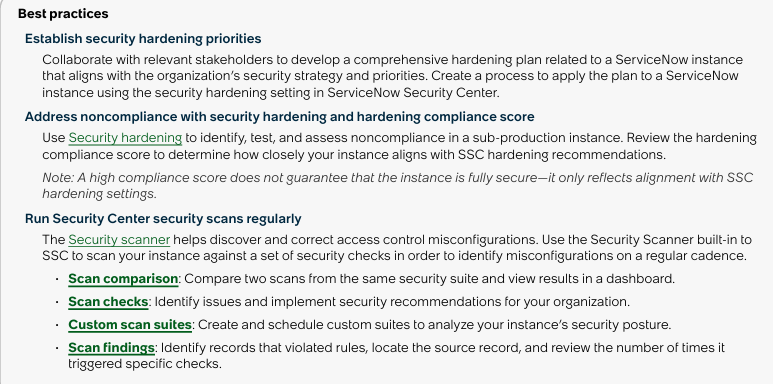

This case is useful for validating that - semantically or lexically close yet irrelevant retrieval is still a confound problem to solve even in fixed domain, fine-tuned, open-book settings